# Evaluation of trajectory inference stability through repeated simulations vor varying velocity estimates
***

Jan T. Schleicher, 2025

Here, we evaluate the hierarchical clustering solutions of exploratory trajectory inference for repeated Markov chain simulations.
This is done for simulations based on transition matrices estimated with different parameters for the number of neighbors and the velocity mode.
We use these repeated analyses to assess the uncertainty of the inferred lineages through comparison of the results of repeated runs.

In [1]:
import glob
import json
import logging
import sys

import cy2path as c2p
import matplotlib as mpl
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from dtaidistance import dtw_ndim
from matplotlib import pyplot as plt

In [2]:
mpl.rcParams["figure.dpi"] = 300
logging.disable(sys.maxsize)

In [3]:
# Import AnnData object
adata = sc.read_h5ad("../data/tex_data_chronic_annotated.h5ad")
adata

AnnData object with n_obs × n_vars = 13410 × 7170
    obs: 'sampleID', 'barcode', 'sample_type', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mitochondrial', 'log1p_total_counts_mitochondrial', 'pct_counts_mitochondrial', 'total_counts_ribosomal', 'log1p_total_counts_ribosomal', 'pct_counts_ribosomal', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_genes', 'n_counts', 'phase', 'S_score', 'G2M_score', 'score_diff', 'leiden', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'annot'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'mitochondrial', 'ribosomal', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'cell_cycle_genes', 'gene_count_corr', 'means', 'dispersions',

In [4]:
# Load clustering results
SIMULATIONS_PATH = "../output/varying_velocity_params/20250810_1458/markov_chains/"
LINEAGE_PATH = "../output/varying_velocity_params/20250810_1458/lineage_clustering/"

n_neighbors_list = [15, 30, 50, 100]
velocity_modes = ["deterministic", "stochastic", "dynamical"]

clusterings_dict = {}
markov_chains_dict = {}
markov_chains_params_dict = {}

for n_neighbors in n_neighbors_list:
    for velocity_mode in velocity_modes:
        clusterings_dict[n_neighbors, velocity_mode] = {}
        markov_chains_dict[n_neighbors, velocity_mode] = {}
        markov_chains_params_dict[n_neighbors, velocity_mode] = {}
        sim_path = f"{SIMULATIONS_PATH}/{n_neighbors}_neighbors_{velocity_mode}"
        for file in glob.glob(f"{sim_path}/simulations_*.npy"):
            run_number = int(file.split("_")[-1].split(".")[0])
            markov_chains_params_dict[n_neighbors, velocity_mode][run_number] = (
                json.load(open(f"{sim_path}/params_{run_number}.json"))
            )
            markov_chains_dict[n_neighbors, velocity_mode][run_number] = np.load(file)[
                :,
                : markov_chains_params_dict[n_neighbors, velocity_mode][run_number][
                    "convergence"
                ],
            ]
            clusterings_dict[n_neighbors, velocity_mode][run_number] = np.load(
                f"{LINEAGE_PATH}/{n_neighbors}_neighbors_{velocity_mode}/lineage_inference_clusters_num_lineages_2_{run_number}.npy"
            )

In [7]:
for (k, v_mode), sub_dict in markov_chains_dict.items():
    for run_number, arr in sub_dict.items():
        print(f"{k}, {v_mode}, run {run_number}: {arr.shape}")

15, deterministic, run 5: (1000, 351)
15, deterministic, run 4: (1000, 351)
15, deterministic, run 6: (1000, 351)
15, deterministic, run 7: (1000, 351)
15, deterministic, run 3: (1000, 351)
15, deterministic, run 2: (1000, 351)
15, deterministic, run 0: (1000, 351)
15, deterministic, run 1: (1000, 351)
15, deterministic, run 9: (1000, 351)
15, deterministic, run 8: (1000, 351)
15, stochastic, run 5: (1000, 267)
15, stochastic, run 4: (1000, 267)
15, stochastic, run 6: (1000, 267)
15, stochastic, run 7: (1000, 267)
15, stochastic, run 3: (1000, 266)
15, stochastic, run 2: (1000, 267)
15, stochastic, run 0: (1000, 267)
15, stochastic, run 1: (1000, 266)
15, stochastic, run 9: (1000, 267)
15, stochastic, run 8: (1000, 266)
15, dynamical, run 5: (1000, 611)
15, dynamical, run 4: (1000, 611)
15, dynamical, run 6: (1000, 611)
15, dynamical, run 7: (1000, 611)
15, dynamical, run 3: (1000, 611)
15, dynamical, run 2: (1000, 611)
15, dynamical, run 0: (1000, 611)
15, dynamical, run 1: (1000, 611

In [13]:
# Compute the trajectory coordinates in PC and UMAP space
n_lineages = 2
trajectories_pca = {}
trajectories_umap = {}
for n_neighbors in n_neighbors_list:
    for velocity_mode in velocity_modes:
        # In some cases, there is one step less than others
        n_steps = min(
            [
                sub_dict["convergence"]
                for sub_dict in markov_chains_params_dict[
                    n_neighbors, velocity_mode
                ].values()
            ]
        )
        trajectories_pca[n_neighbors, velocity_mode] = {}
        trajectories_umap[n_neighbors, velocity_mode] = {}
        for run_number, markov_chains in markov_chains_dict[
            n_neighbors, velocity_mode
        ].items():
            trajectories_pca[n_neighbors, velocity_mode][run_number] = np.zeros(
                (n_lineages, n_steps, adata.obsm["X_pca"].shape[1]), dtype="double"
            )
            trajectories_umap[n_neighbors, velocity_mode][run_number] = np.zeros(
                (n_lineages, n_steps, adata.obsm["X_umap"].shape[1])
            )
            clustering = clusterings_dict[n_neighbors, velocity_mode][run_number]
            for i in range(n_lineages):
                indices = np.where(clustering == i + 1)[0]
                chains = markov_chains[indices, :n_steps]
                trajectories_pca[n_neighbors, velocity_mode][run_number][i, :, :] = (
                    np.median(adata.obsm["X_pca"][chains], axis=0)
                )
                trajectories_umap[n_neighbors, velocity_mode][run_number][i, :, :] = (
                    np.median(adata.obsm["X_umap"][chains], axis=0)
                )

In [17]:
# Compute lineage mapping between runs, using lineages from first run as reference
# Output for each run and n_lineages is the order of lineages matching the reference lineages
lineage_orders = {}
for n_neighbors in n_neighbors_list:
    for velocity_mode in velocity_modes:
        lineage_orders[n_neighbors, velocity_mode] = [list(range(n_lineages))]
        ref_trajectory = trajectories_pca[n_neighbors, velocity_mode][0]
        for run_number in range(1, len(trajectories_pca[n_neighbors, velocity_mode])):
            trajectory_coords = trajectories_pca[n_neighbors, velocity_mode][run_number]
            dist_mat = dtw_ndim.distance_matrix_fast(
                np.vstack([ref_trajectory, trajectory_coords]),
                block=((0, n_lineages), (n_lineages, 2 * n_lineages)),
            )[:n_lineages, n_lineages:]
            mapping = {}
            # Greedily choose the argmin as the mapping
            for i in range(n_lineages):
                idx_ref, idx_other = np.unravel_index(dist_mat.argmin(), dist_mat.shape)
                mapping[idx_ref] = idx_other
                # Remove rows and cols that are already mapped
                dist_mat[idx_ref, :] = np.inf
                dist_mat[:, idx_other] = np.inf
            lineage_orders[n_neighbors, velocity_mode].append(
                [mapping[i] for i in range(n_lineages)]
            )

In [18]:
# Compute mean and std of inferred UMAP coordinates
lineage_coords_all = {}
for n_neighbors in n_neighbors_list:
    for velocity_mode in velocity_modes:
        lineage_coords_all[n_neighbors, velocity_mode] = np.stack(
            [
                trajectories_umap[n_neighbors, velocity_mode][run_number][
                    lineage_orders[n_neighbors, velocity_mode][run_number]
                ]
                for run_number in range(
                    len(trajectories_umap[n_neighbors, velocity_mode])
                )
            ]
        )
lineage_coords_mean = {
    key: np.mean(coords, axis=0) for key, coords in lineage_coords_all.items()
}
lineage_coords_std = {
    key: np.std(coords, axis=0) for key, coords in lineage_coords_all.items()
}

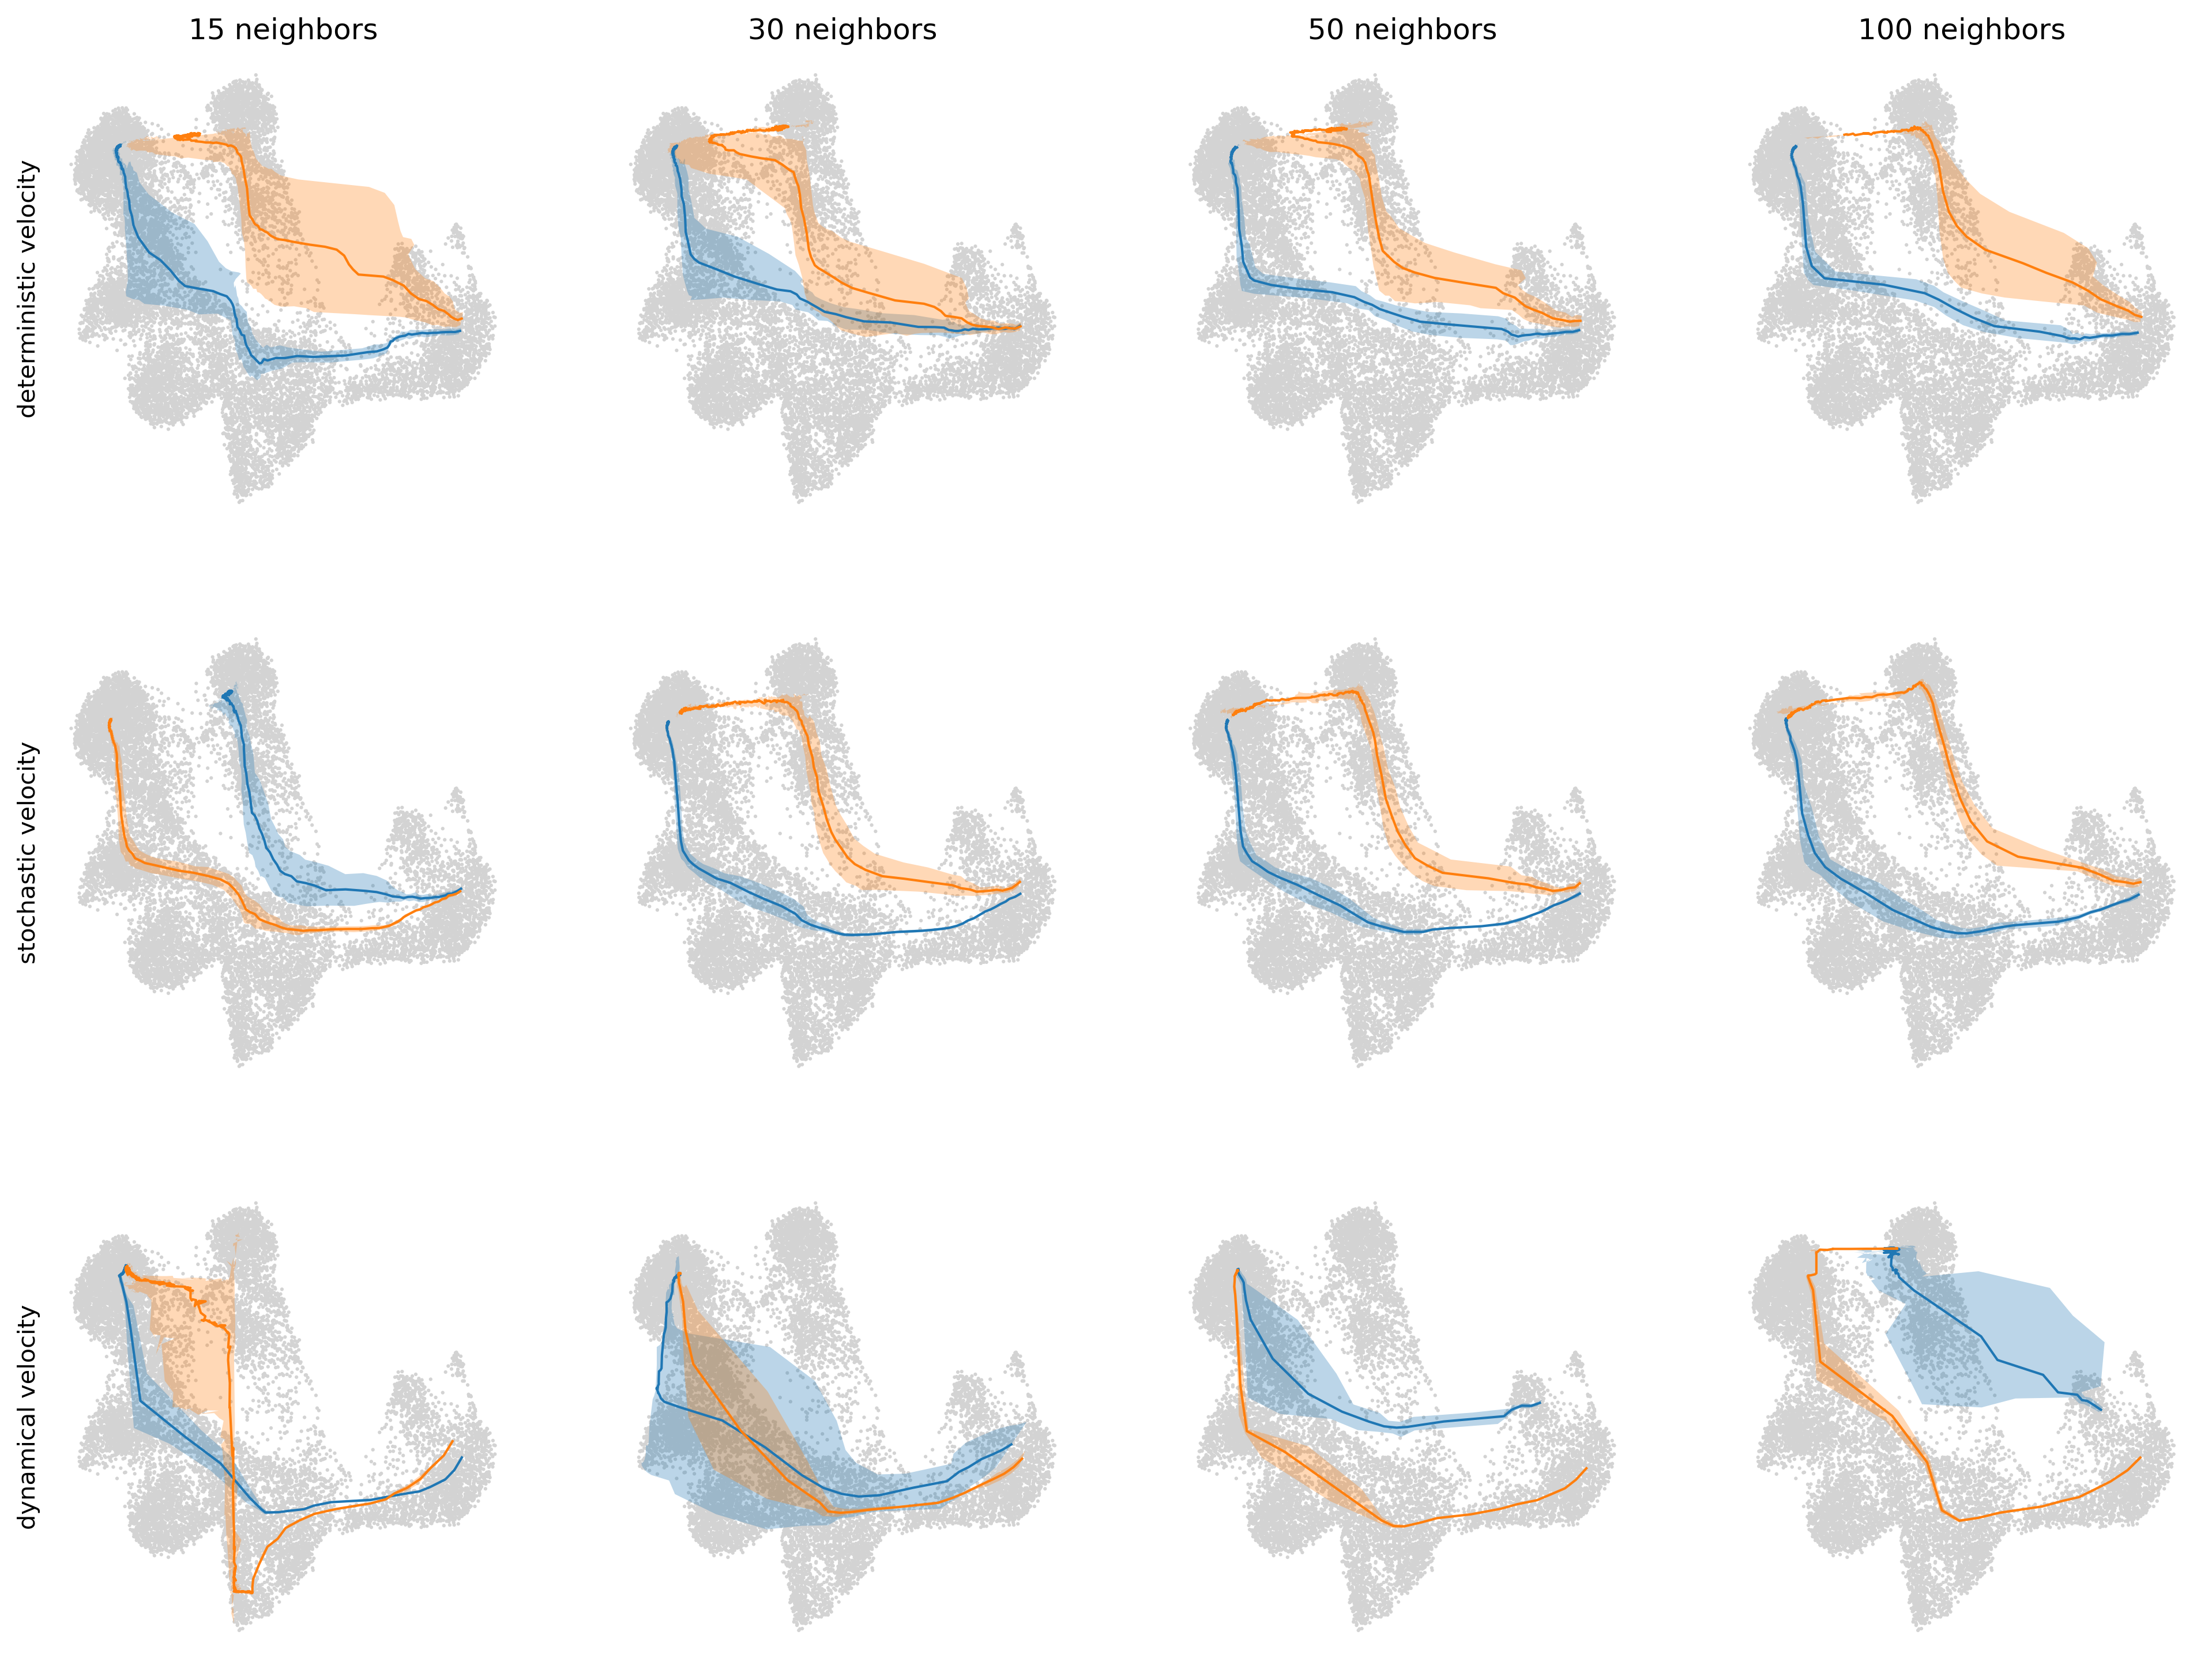

In [20]:
# Plot trajectories and their uncertainty
fig, axs = plt.subplots(3, 4, figsize=(16, 12))
for row_idx, velocity_mode in enumerate(velocity_modes):
    for col_idx, n_neighbors in enumerate(n_neighbors_list):
        ax = axs[row_idx, col_idx]
        sc.pl.umap(adata, ax=ax, show=False)
        for j, lineage in enumerate(lineage_coords_mean[n_neighbors, velocity_mode]):
            color = f"C{j}"
            ax.plot(lineage[:, 0], lineage[:, 1], lw=1, c=color)
            region_lower = lineage - lineage_coords_std[n_neighbors, velocity_mode][j]
            region_upper = lineage + lineage_coords_std[n_neighbors, velocity_mode][j]
            xf = np.concatenate((region_lower[:, 0], region_upper[:, 0][::-1]))
            yf = np.concatenate((region_lower[:, 1], region_upper[:, 1][::-1]))
            ax.fill(xf, yf, c=color, alpha=0.3, lw=0)
        if row_idx == 0:
            ax.set_title(f"{n_neighbors} neighbors")
        else:
            ax.set_title("")
        if col_idx == 0:
            ax.set_ylabel(f"{velocity_mode} velocity")
        else:
            ax.set_ylabel("")
        ax.set_xlabel("")
sns.despine(fig, bottom=True, left=True)

In [21]:
# Compute mean and variance of inferred PCA trajectories
lineage_coords_all_pca = {}
for n_neighbors in n_neighbors_list:
    for velocity_mode in velocity_modes:
        lineage_coords_all_pca[n_neighbors, velocity_mode] = np.stack(
            [
                trajectories_pca[n_neighbors, velocity_mode][run_number][
                    lineage_orders[n_neighbors, velocity_mode][run_number]
                ]
                for run_number in range(
                    len(trajectories_pca[n_neighbors, velocity_mode])
                )
            ]
        )
lineage_coords_mean_pca = {
    key: np.mean(coords, axis=0) for key, coords in lineage_coords_all_pca.items()
}
lineage_coords_var_pca = {
    key: np.var(coords, axis=0, ddof=1)
    for key, coords in lineage_coords_all_pca.items()
}
lineage_coords_var_sum_pca = {
    key: var.sum(axis=2) for key, var in lineage_coords_var_pca.items()
}

In [23]:
for (n_neighbors, velocity_mode), coords in lineage_coords_all.items():
    np.save(
        f"{LINEAGE_PATH}/{n_neighbors}_neighbors_{velocity_mode}/lineage_coords_all.npy",
        coords,
    )
    np.save(
        f"{LINEAGE_PATH}/{n_neighbors}_neighbors_{velocity_mode}/lineage_coords_mean.npy",
        lineage_coords_mean[n_neighbors, velocity_mode],
    )
    np.save(
        f"{LINEAGE_PATH}/{n_neighbors}_neighbors_{velocity_mode}/lineage_coords_std.npy",
        lineage_coords_std[n_neighbors, velocity_mode],
    )
    np.save(
        f"{LINEAGE_PATH}/{n_neighbors}_neighbors_{velocity_mode}/lineage_coords_all_pca.npy",
        lineage_coords_all_pca[n_neighbors, velocity_mode],
    )
    np.save(
        f"{LINEAGE_PATH}/{n_neighbors}_neighbors_{velocity_mode}/lineage_coords_mean_pca.npy",
        lineage_coords_mean_pca[n_neighbors, velocity_mode],
    )
    np.save(
        f"{LINEAGE_PATH}/{n_neighbors}_neighbors_{velocity_mode}/lineage_coords_var_pca.npy",
        lineage_coords_var_pca[n_neighbors, velocity_mode],
    )
    np.save(
        f"{LINEAGE_PATH}/{n_neighbors}_neighbors_{velocity_mode}/lineage_coords_var_sum_pca.npy",
        lineage_coords_var_sum_pca[n_neighbors, velocity_mode],
    )

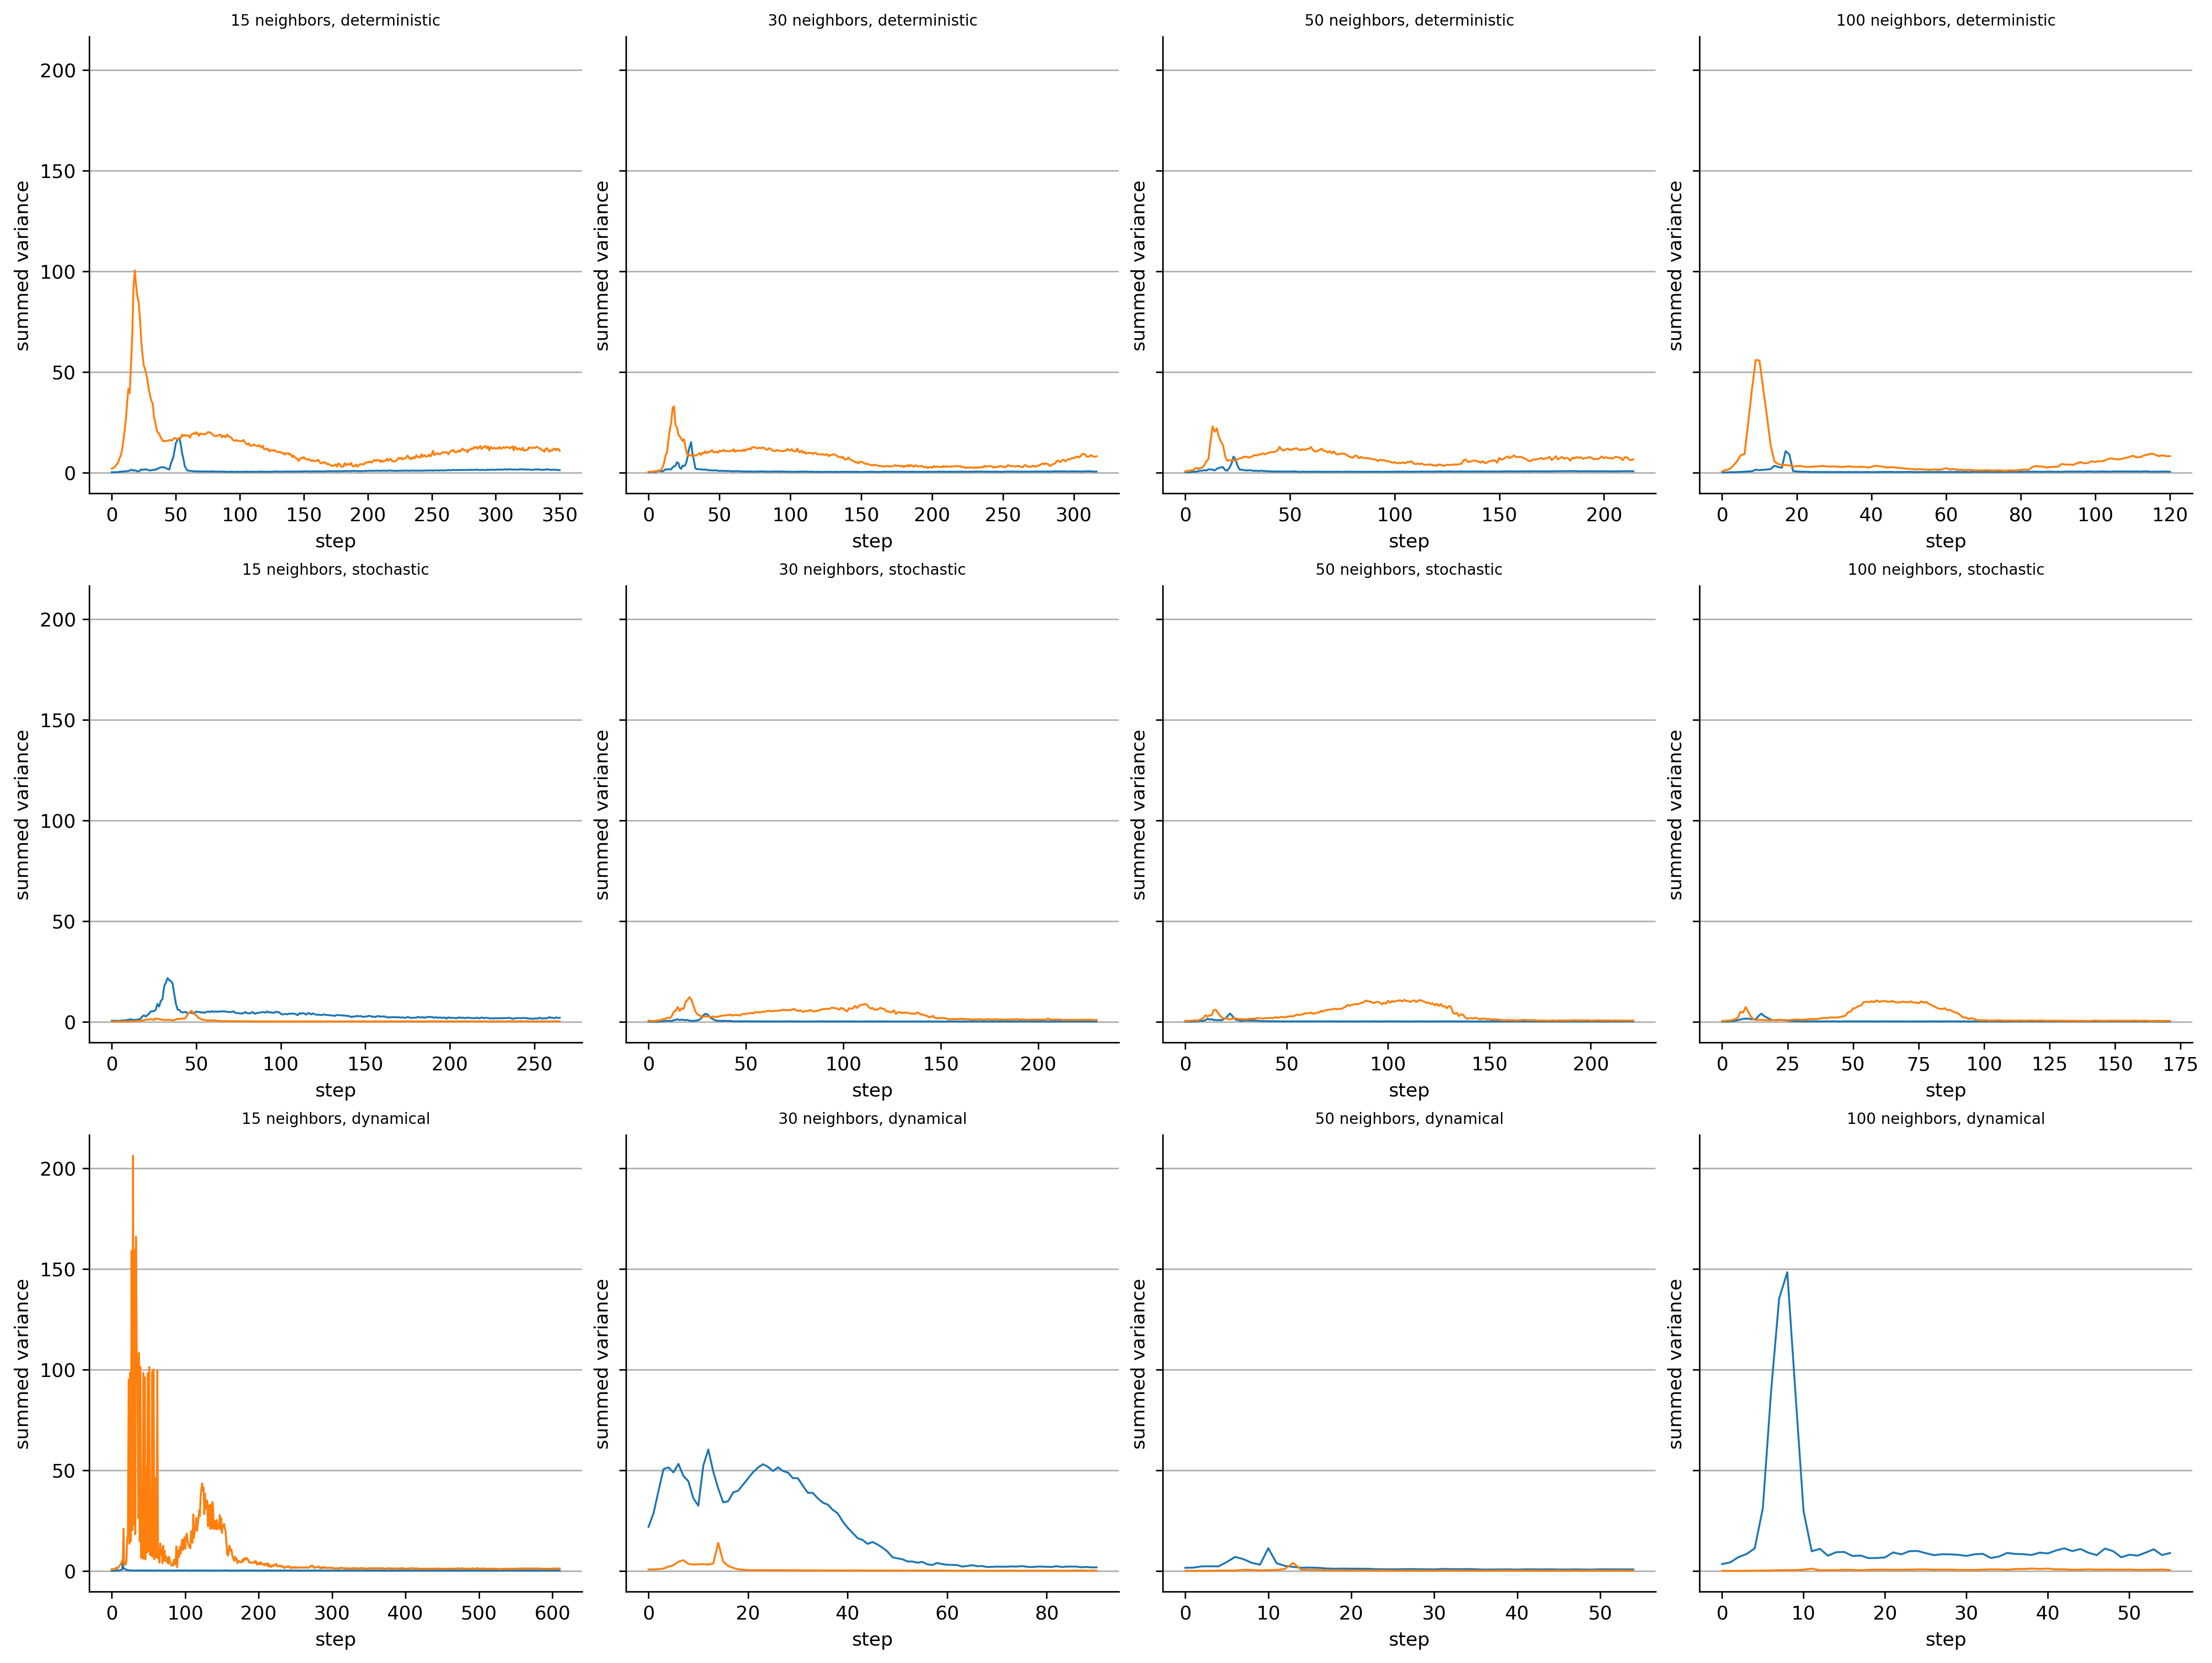

In [26]:
# Plot sum of trajectory variances in PCA space for each step
fig, axs = plt.subplots(3, 4, figsize=(16, 12), layout="constrained", sharey=True)
for row_idx, velocity_mode in enumerate(velocity_modes):
    for col_idx, n_neighbors in enumerate(n_neighbors_list):
        ax = axs[row_idx, col_idx]
        for j, traces in enumerate(
            lineage_coords_var_sum_pca[n_neighbors, velocity_mode]
        ):
            color = f"C{j}"
            ax.plot(np.arange(traces.shape[0]), traces, lw=1, c=color)
        ax.set_title(f"{n_neighbors} neighbors, {velocity_mode}", fontsize=8)
        ax.set_xlabel("step")
        ax.set_ylabel("summed variance")
        ax.grid(axis="y")
sns.despine(fig)

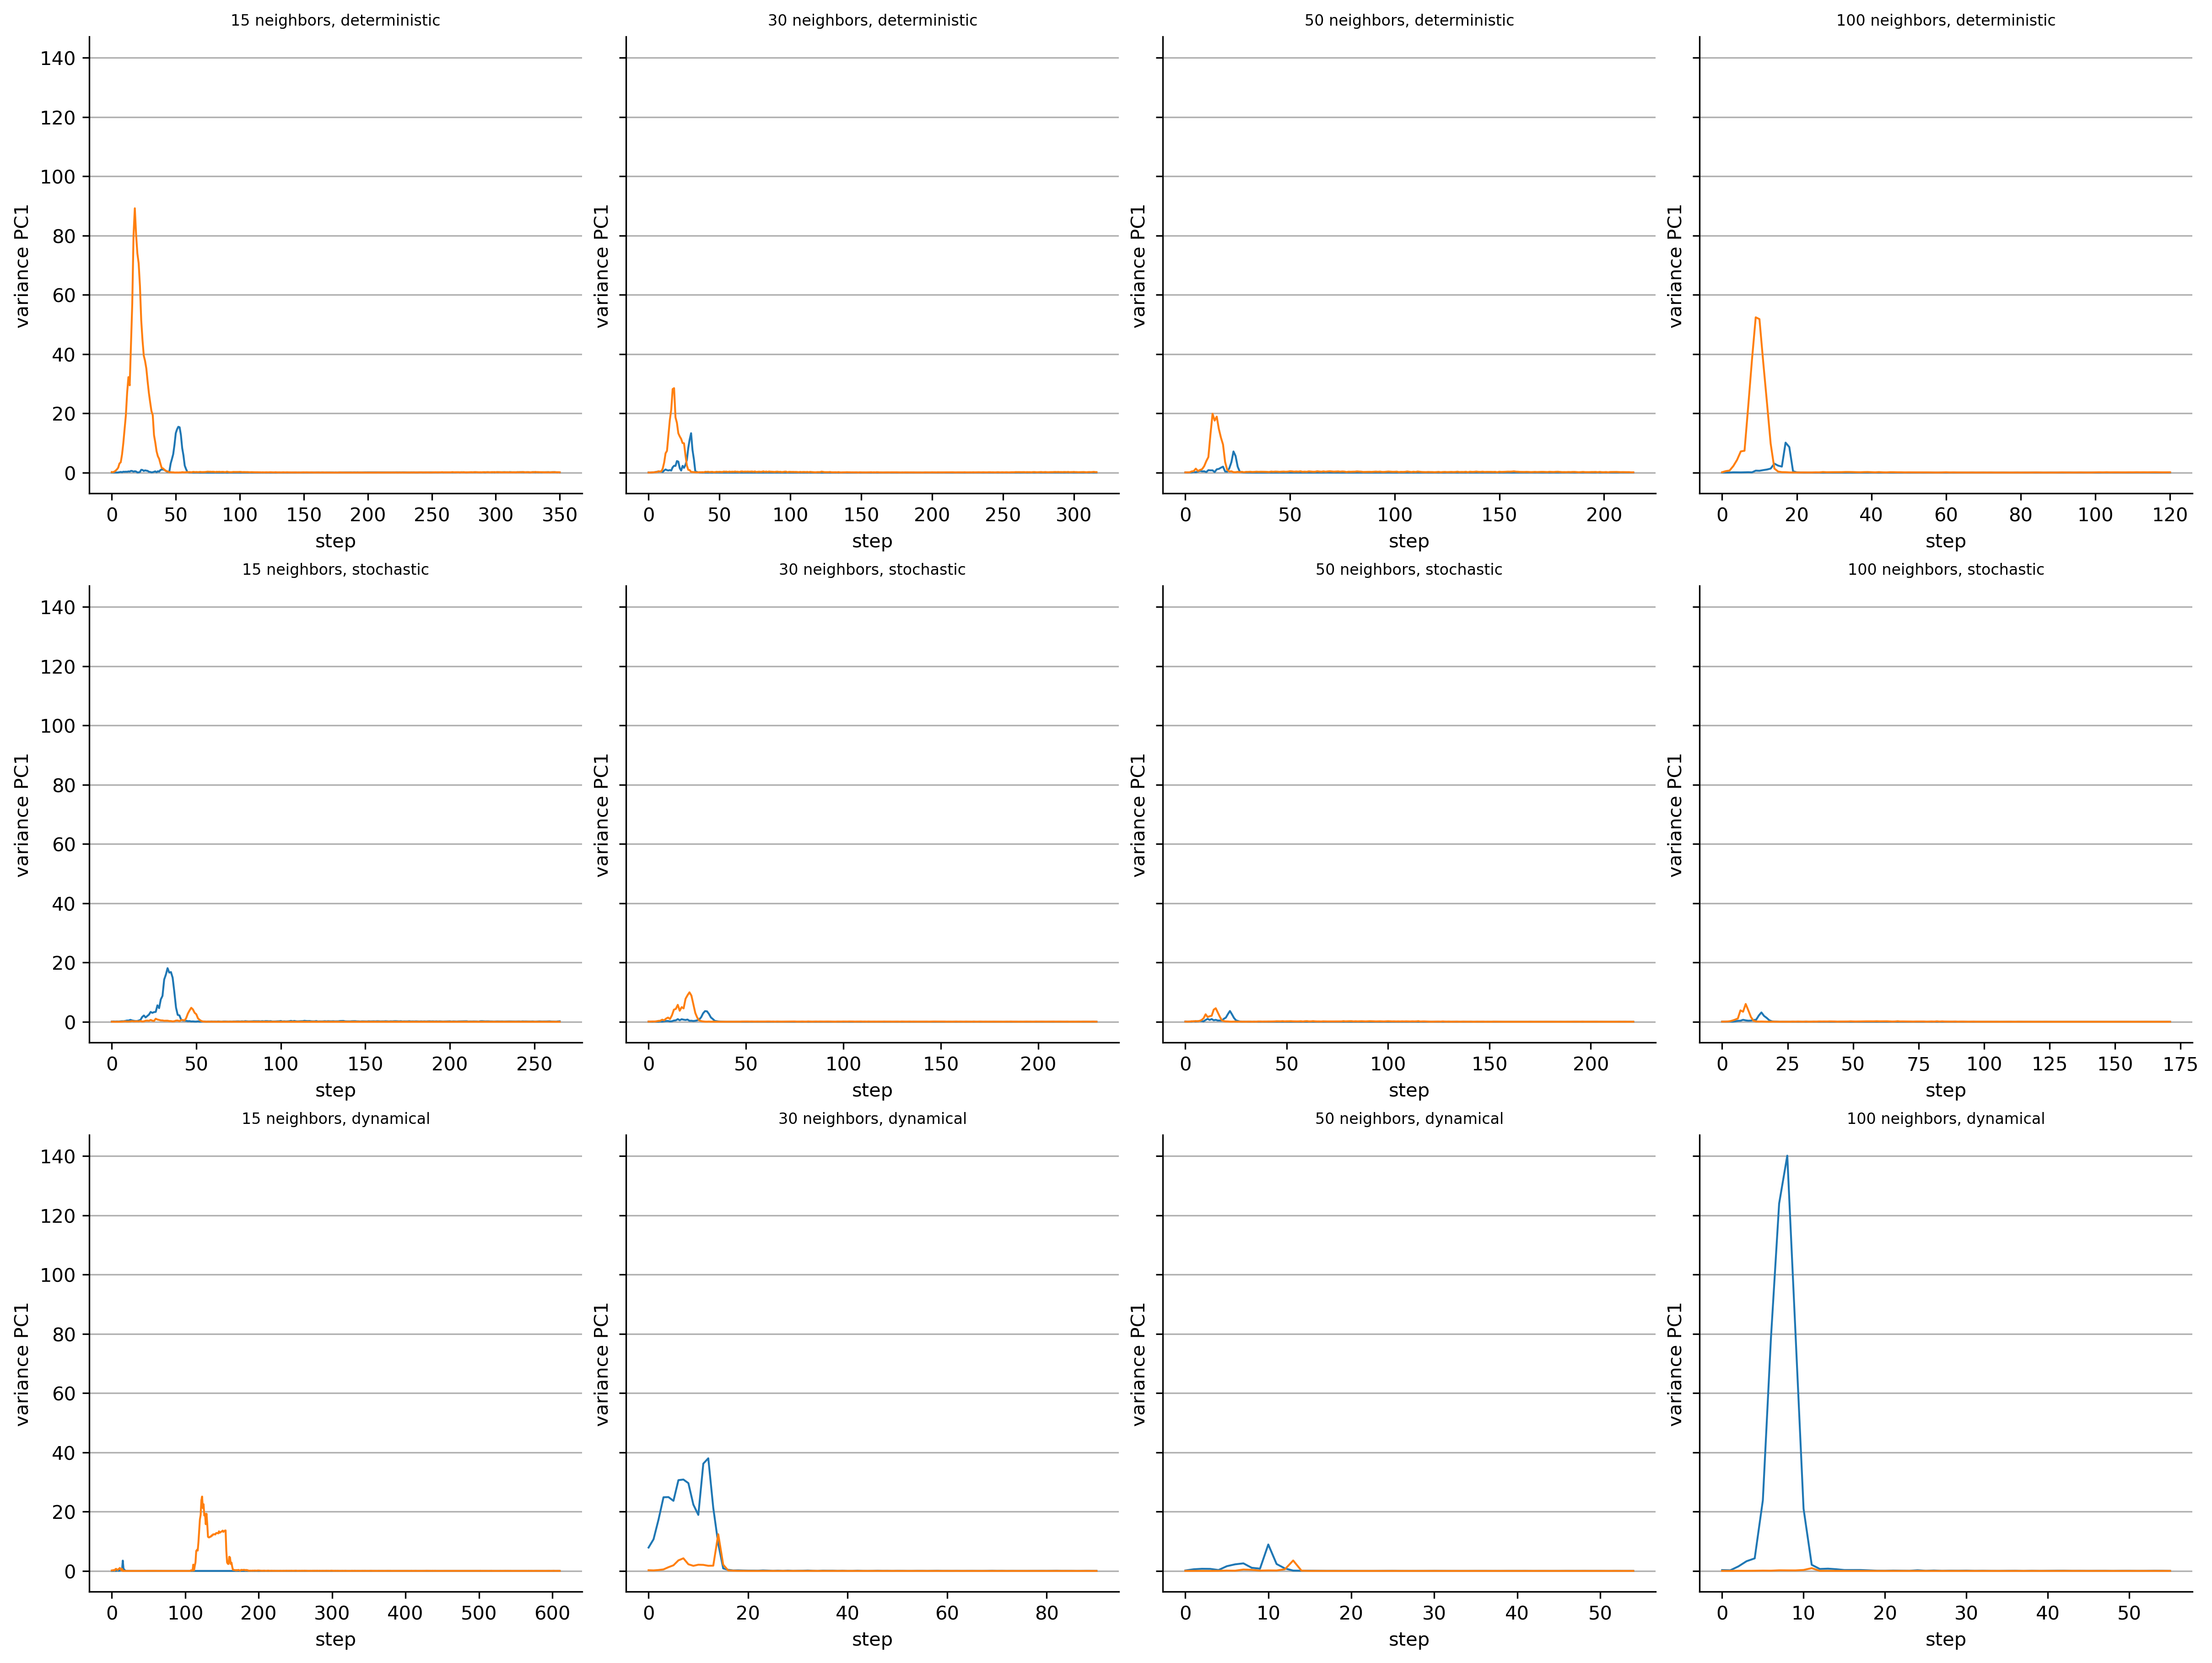

In [27]:
# Plot variances for first PC for each step
fig, axs = plt.subplots(3, 4, figsize=(16, 12), layout="constrained", sharey=True)
for row_idx, velocity_mode in enumerate(velocity_modes):
    for col_idx, n_neighbors in enumerate(n_neighbors_list):
        ax = axs[row_idx, col_idx]
        for j, variances in enumerate(
            lineage_coords_var_pca[n_neighbors, velocity_mode]
        ):
            color = f"C{j}"
            ax.plot(np.arange(variances.shape[0]), variances[:, 0], lw=1, c=color)
        ax.set_title(f"{n_neighbors} neighbors, {velocity_mode}", fontsize=8)
        ax.set_xlabel("step")
        ax.set_ylabel("variance PC1")
        ax.grid(axis="y")
sns.despine(fig)

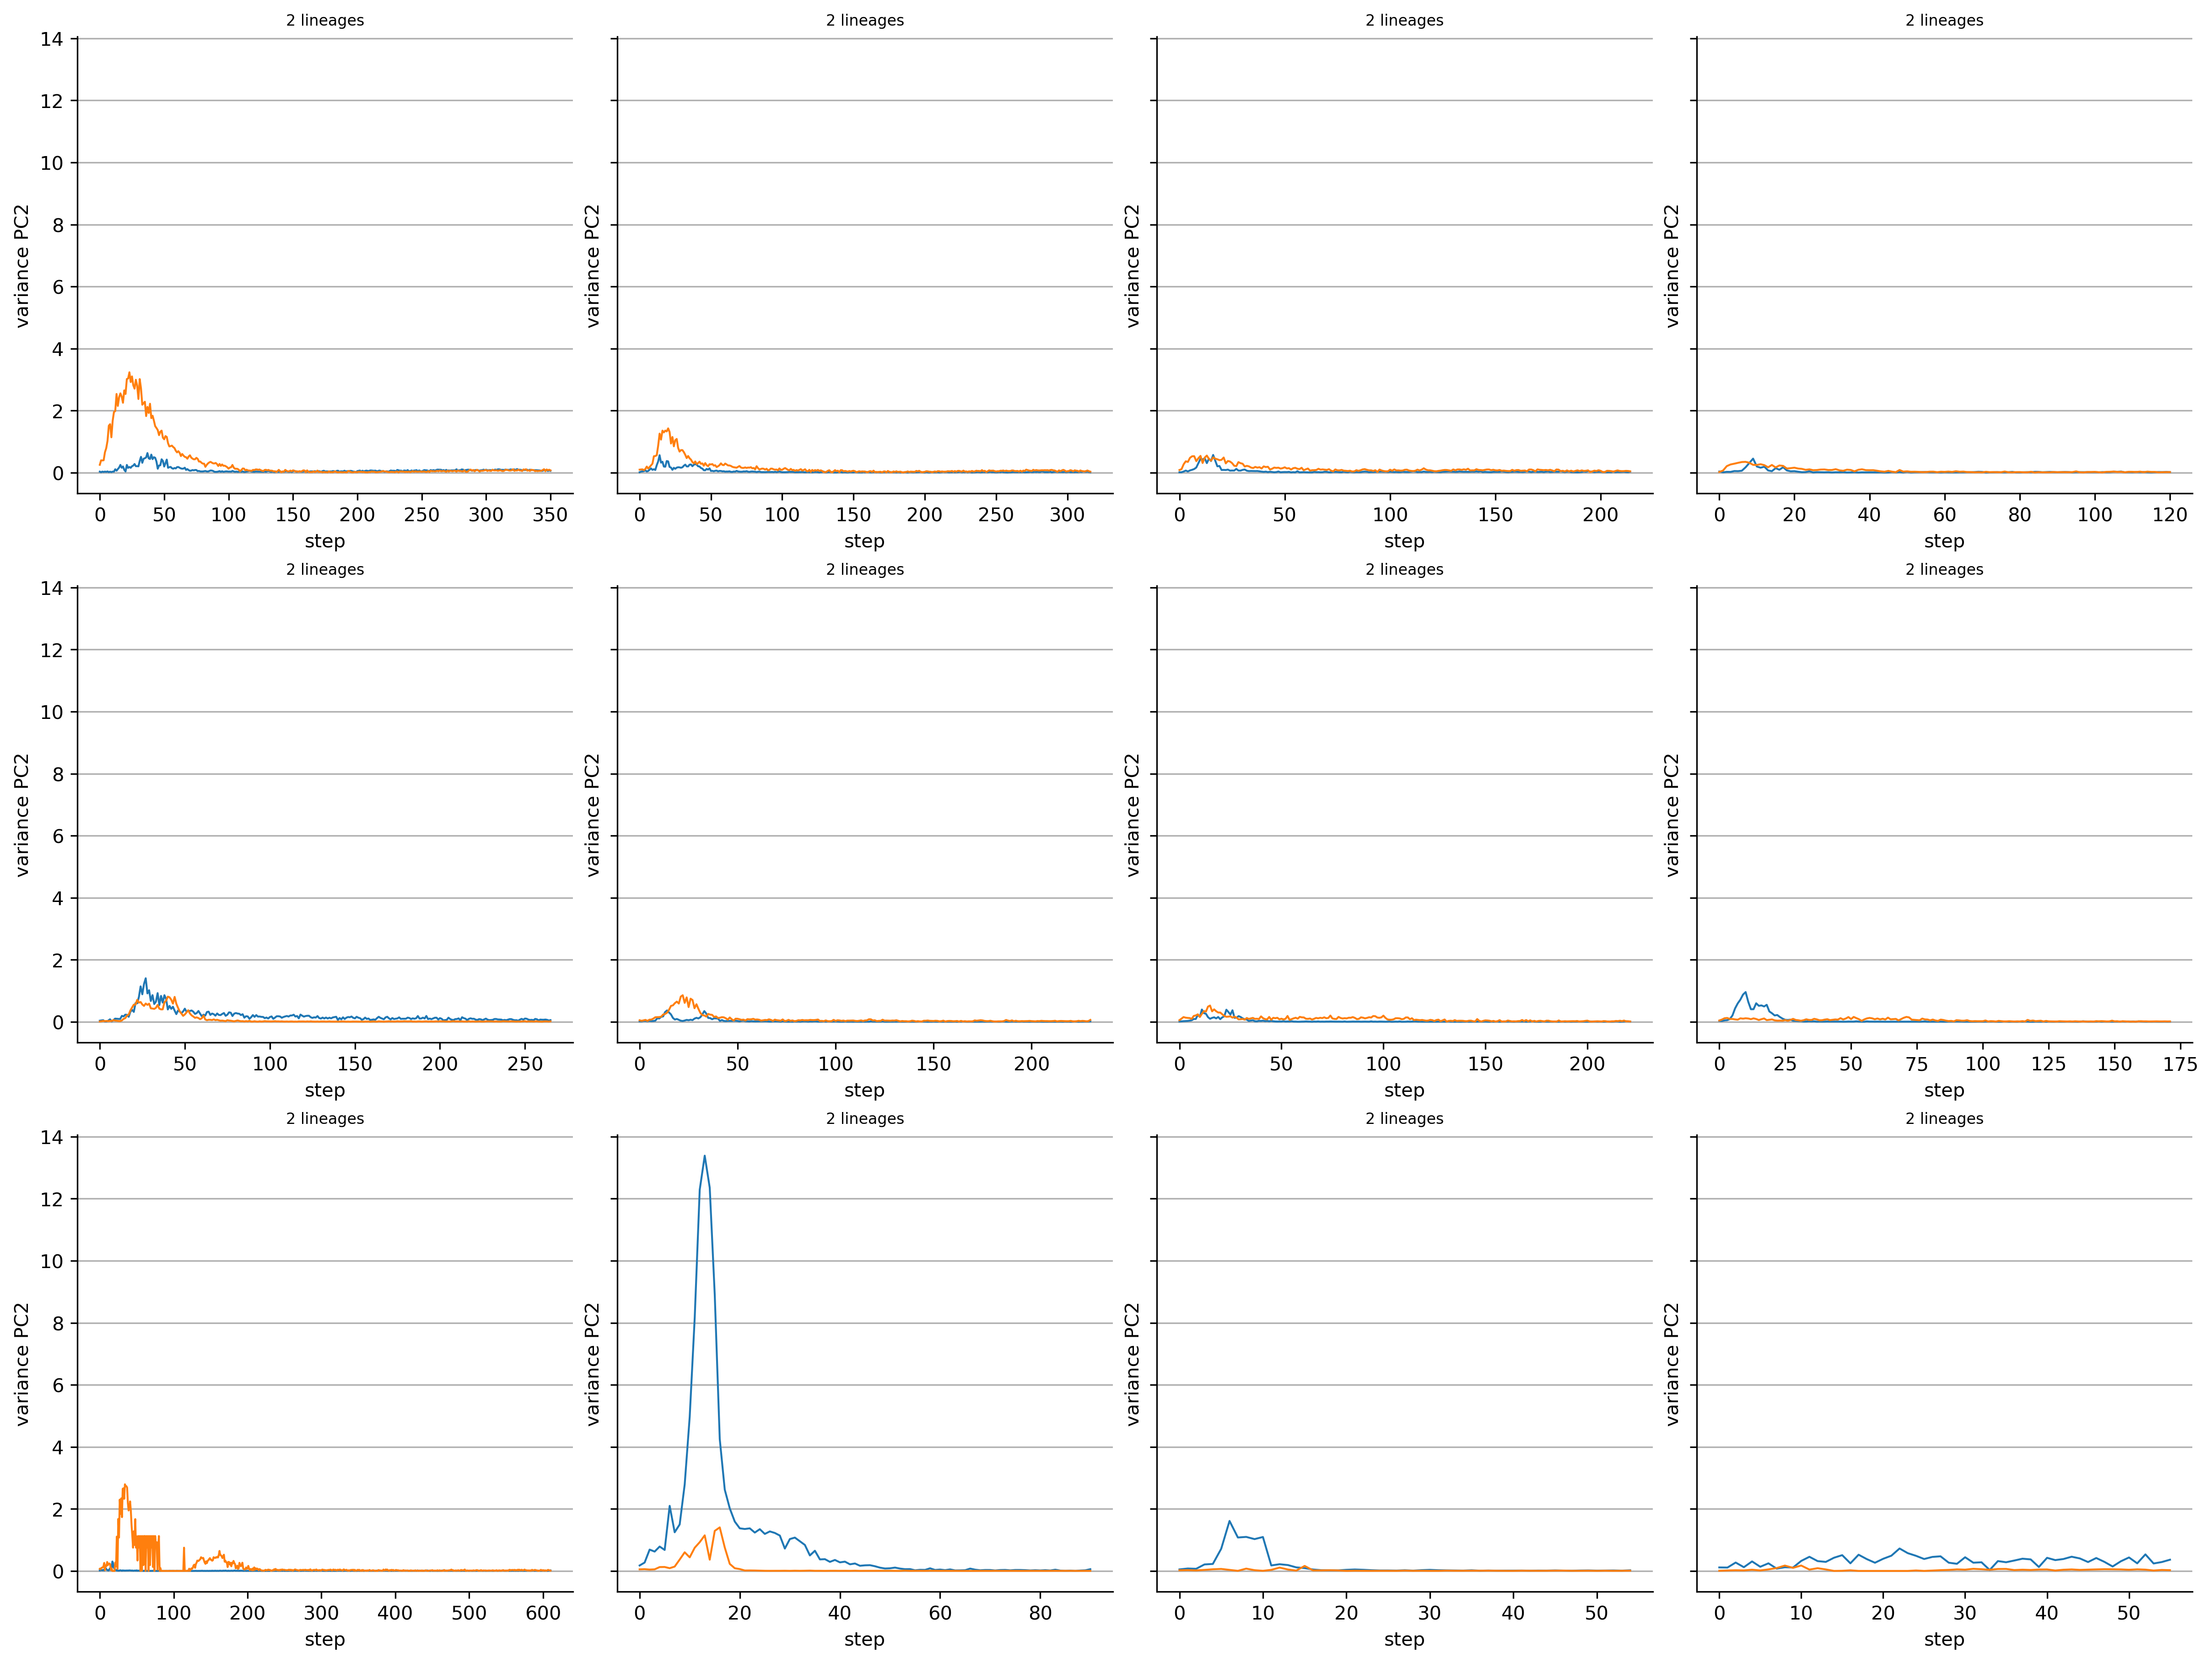

In [28]:
# Plot variances for second PC for each step
fig, axs = plt.subplots(3, 4, figsize=(16, 12), layout="constrained", sharey=True)
for row_idx, velocity_mode in enumerate(velocity_modes):
    for col_idx, n_neighbors in enumerate(n_neighbors_list):
        ax = axs[row_idx, col_idx]
        for j, variances in enumerate(
            lineage_coords_var_pca[n_neighbors, velocity_mode]
        ):
            color = f"C{j}"
            ax.plot(np.arange(variances.shape[0]), variances[:, 1], lw=1, c=color)
        ax.set_title(f"{n_lineages} lineages", fontsize=8)
        ax.set_xlabel("step")
        ax.set_ylabel("variance PC2")
        ax.grid(axis="y")
sns.despine(fig)

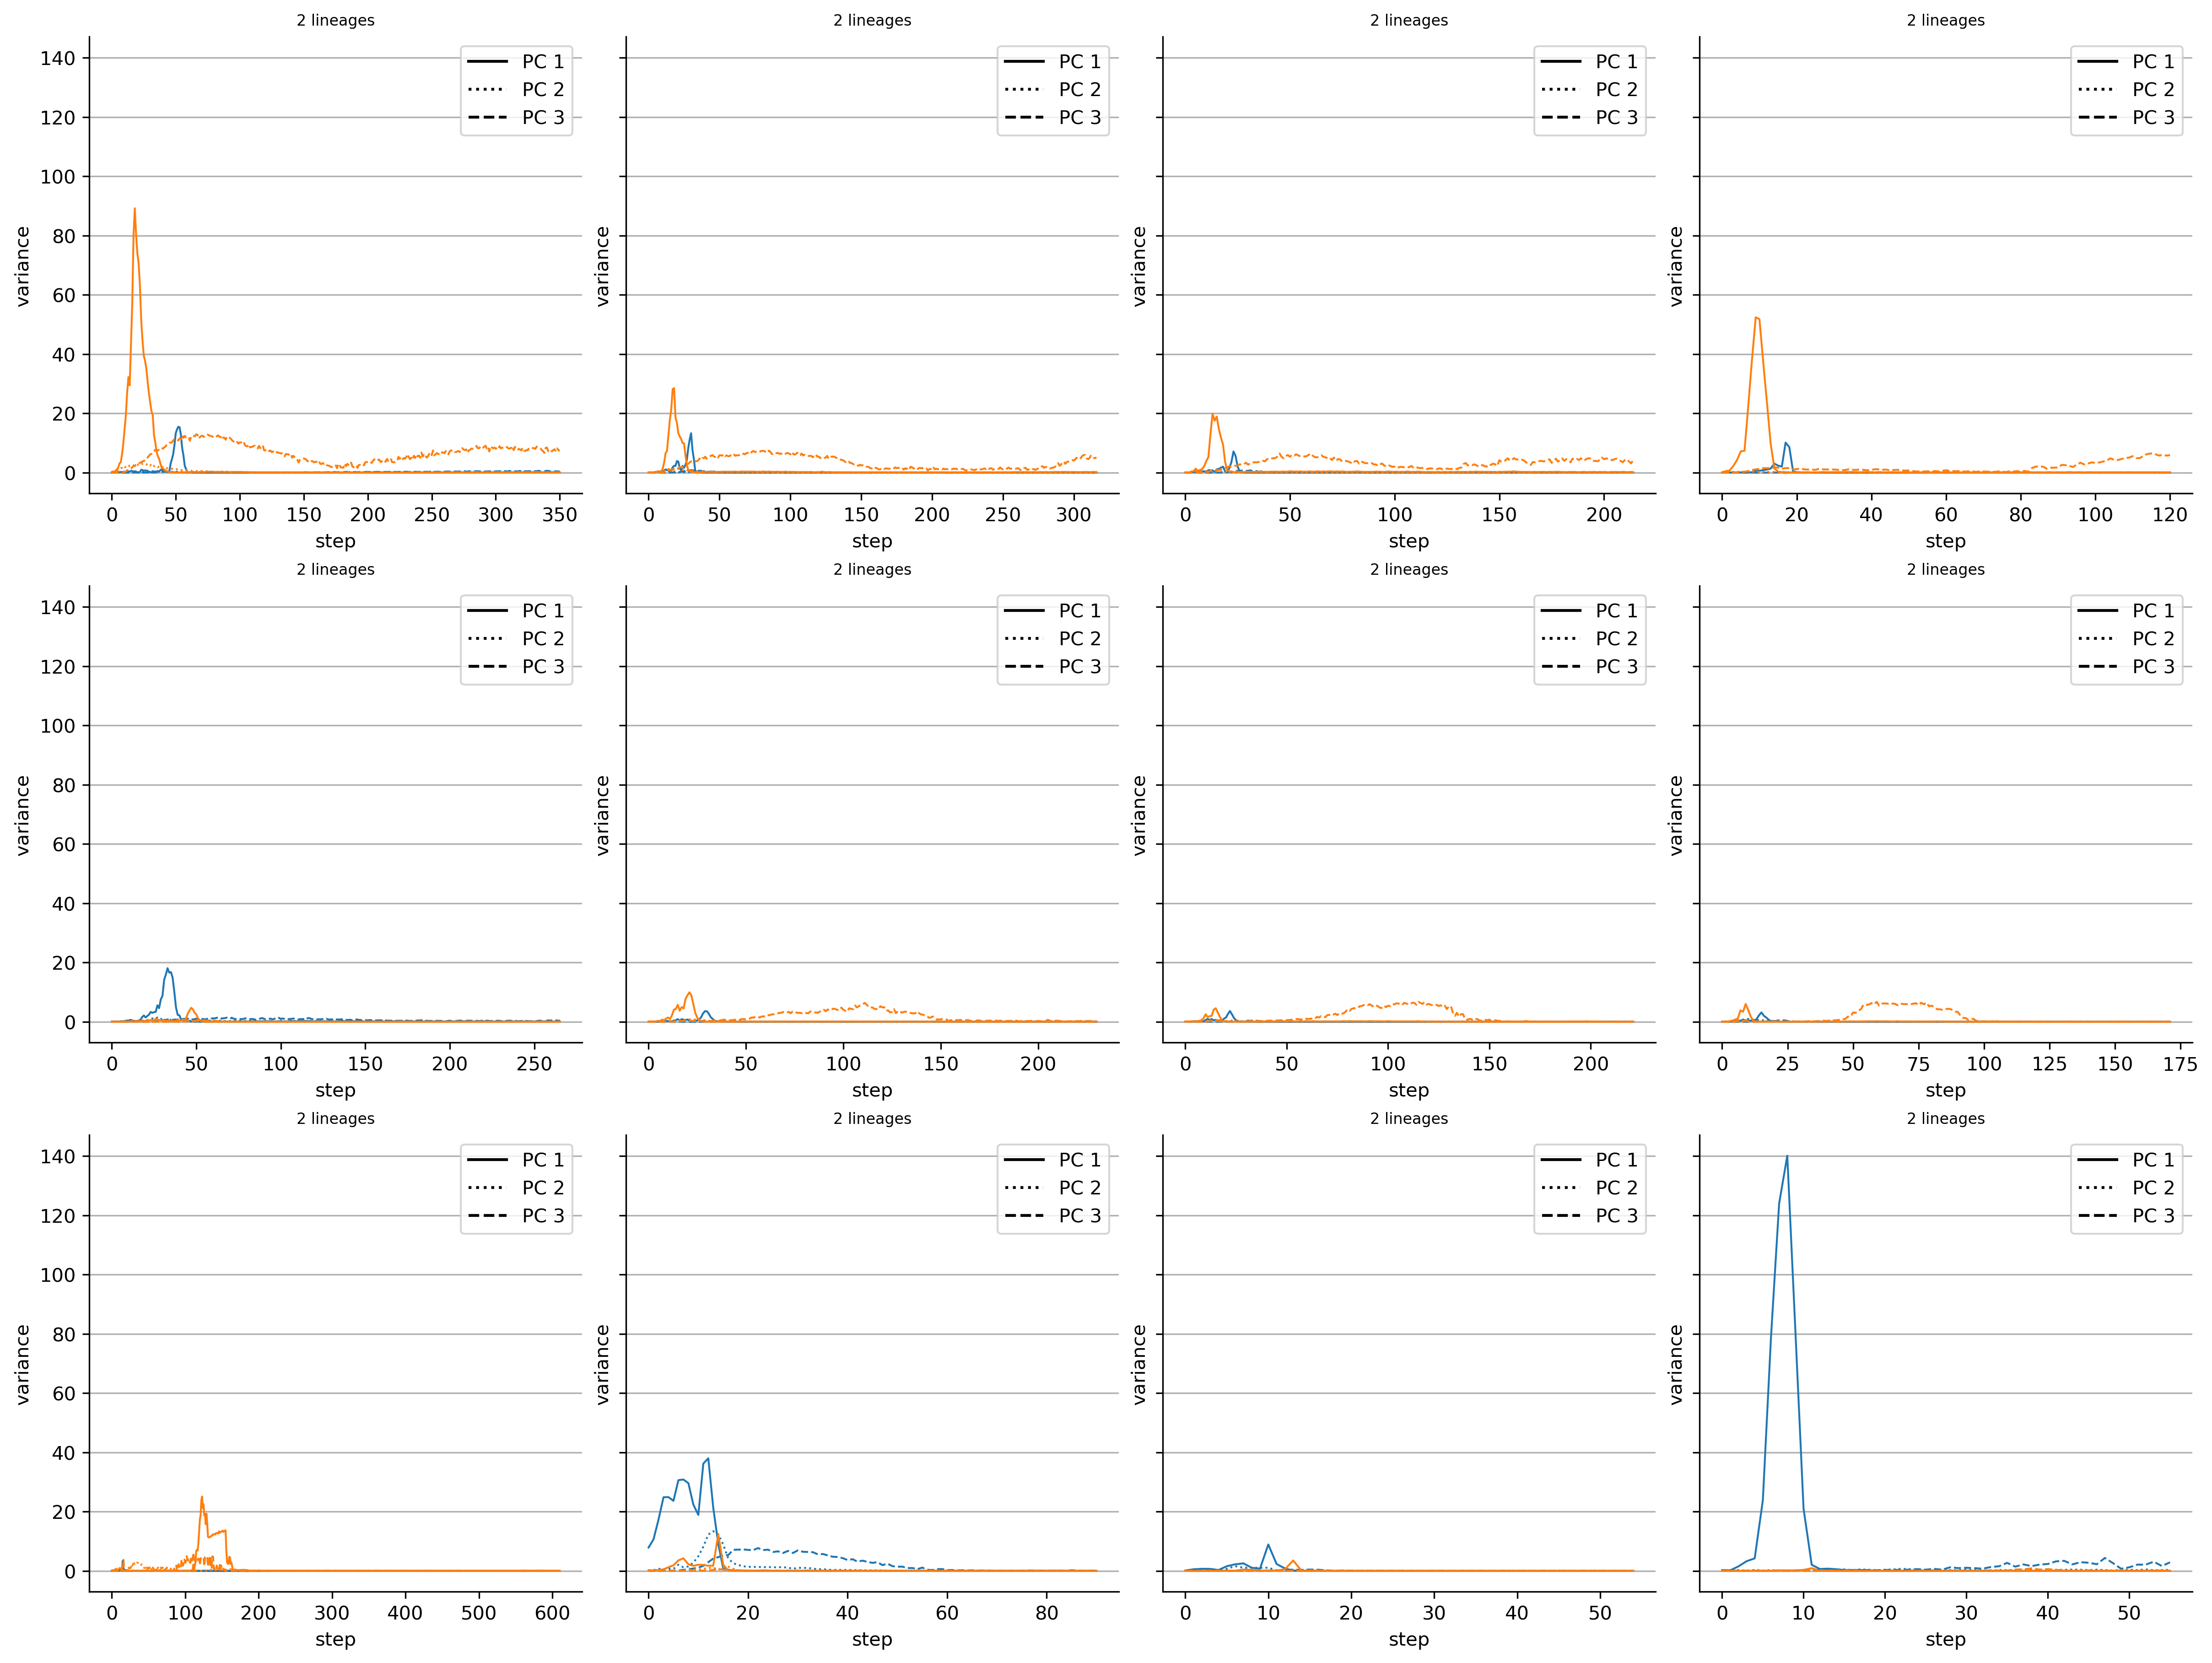

In [29]:
# Plot variances for multiple PCs for each step
fig, axs = plt.subplots(3, 4, figsize=(16, 12), layout="constrained", sharey=True)
for row_idx, velocity_mode in enumerate(velocity_modes):
    for col_idx, n_neighbors in enumerate(n_neighbors_list):
        ax = axs[row_idx, col_idx]
        for j, variances in enumerate(
            lineage_coords_var_pca[n_neighbors, velocity_mode]
        ):
            color = f"C{j}"
            for pc, linestyle in enumerate(["solid", "dotted", "dashed"]):
                ax.plot(
                    np.arange(variances.shape[0]),
                    variances[:, pc],
                    lw=1,
                    c=color,
                    linestyle=linestyle,
                    label=f"PC {pc + 1}",
                )
        handles = [
            mpl.lines.Line2D([], [], color="k", linestyle=ls)
            for ls in ["solid", "dotted", "dashed"]
        ]
        labels = [f"PC {i + 1}" for i in range(3)]
        ax.legend(handles, labels, loc="upper right")
        ax.set_title(f"{n_lineages} lineages", fontsize=8)
        ax.set_xlabel("step")
        ax.set_ylabel("variance")
        ax.grid(axis="y")
sns.despine(fig)

In [30]:
def colored_line(x, y, c, ax, **lc_kwargs):
    """
    Plot a line with a color specified along the line by a third value.

    It does this by creating a collection of line segments. Each line segment is
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Code taken from https://matplotlib.org/stable/gallery/lines_bars_and_markers/multicolored_line.html

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should be the same size as x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """

    # Default the capstyle to butt so that the line segments smoothly line up
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)

    # Compute the midpoints of the line segments. Include the first and last points
    # twice so we don't need any special syntax later to handle them.
    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

    # Determine the start, middle, and end coordinate pair of each line segment.
    # Use the reshape to add an extra dimension so each pair of points is in its
    # own list. Then concatenate them to create:
    # [
    #   [(x1_start, y1_start), (x1_mid, y1_mid), (x1_end, y1_end)],
    #   [(x2_start, y2_start), (x2_mid, y2_mid), (x2_end, y2_end)],
    #   ...
    # ]
    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    lc = mpl.collections.LineCollection(segments, **default_kwargs)
    lc.set_array(c)  # set the colors of each segment

    return ax.add_collection(lc)

In [31]:
norm_var = mpl.colors.Normalize(
    vmin=0, vmax=np.max([arr.max() for arr in lineage_coords_var_sum_pca.values()])
)
cmap = "Reds"

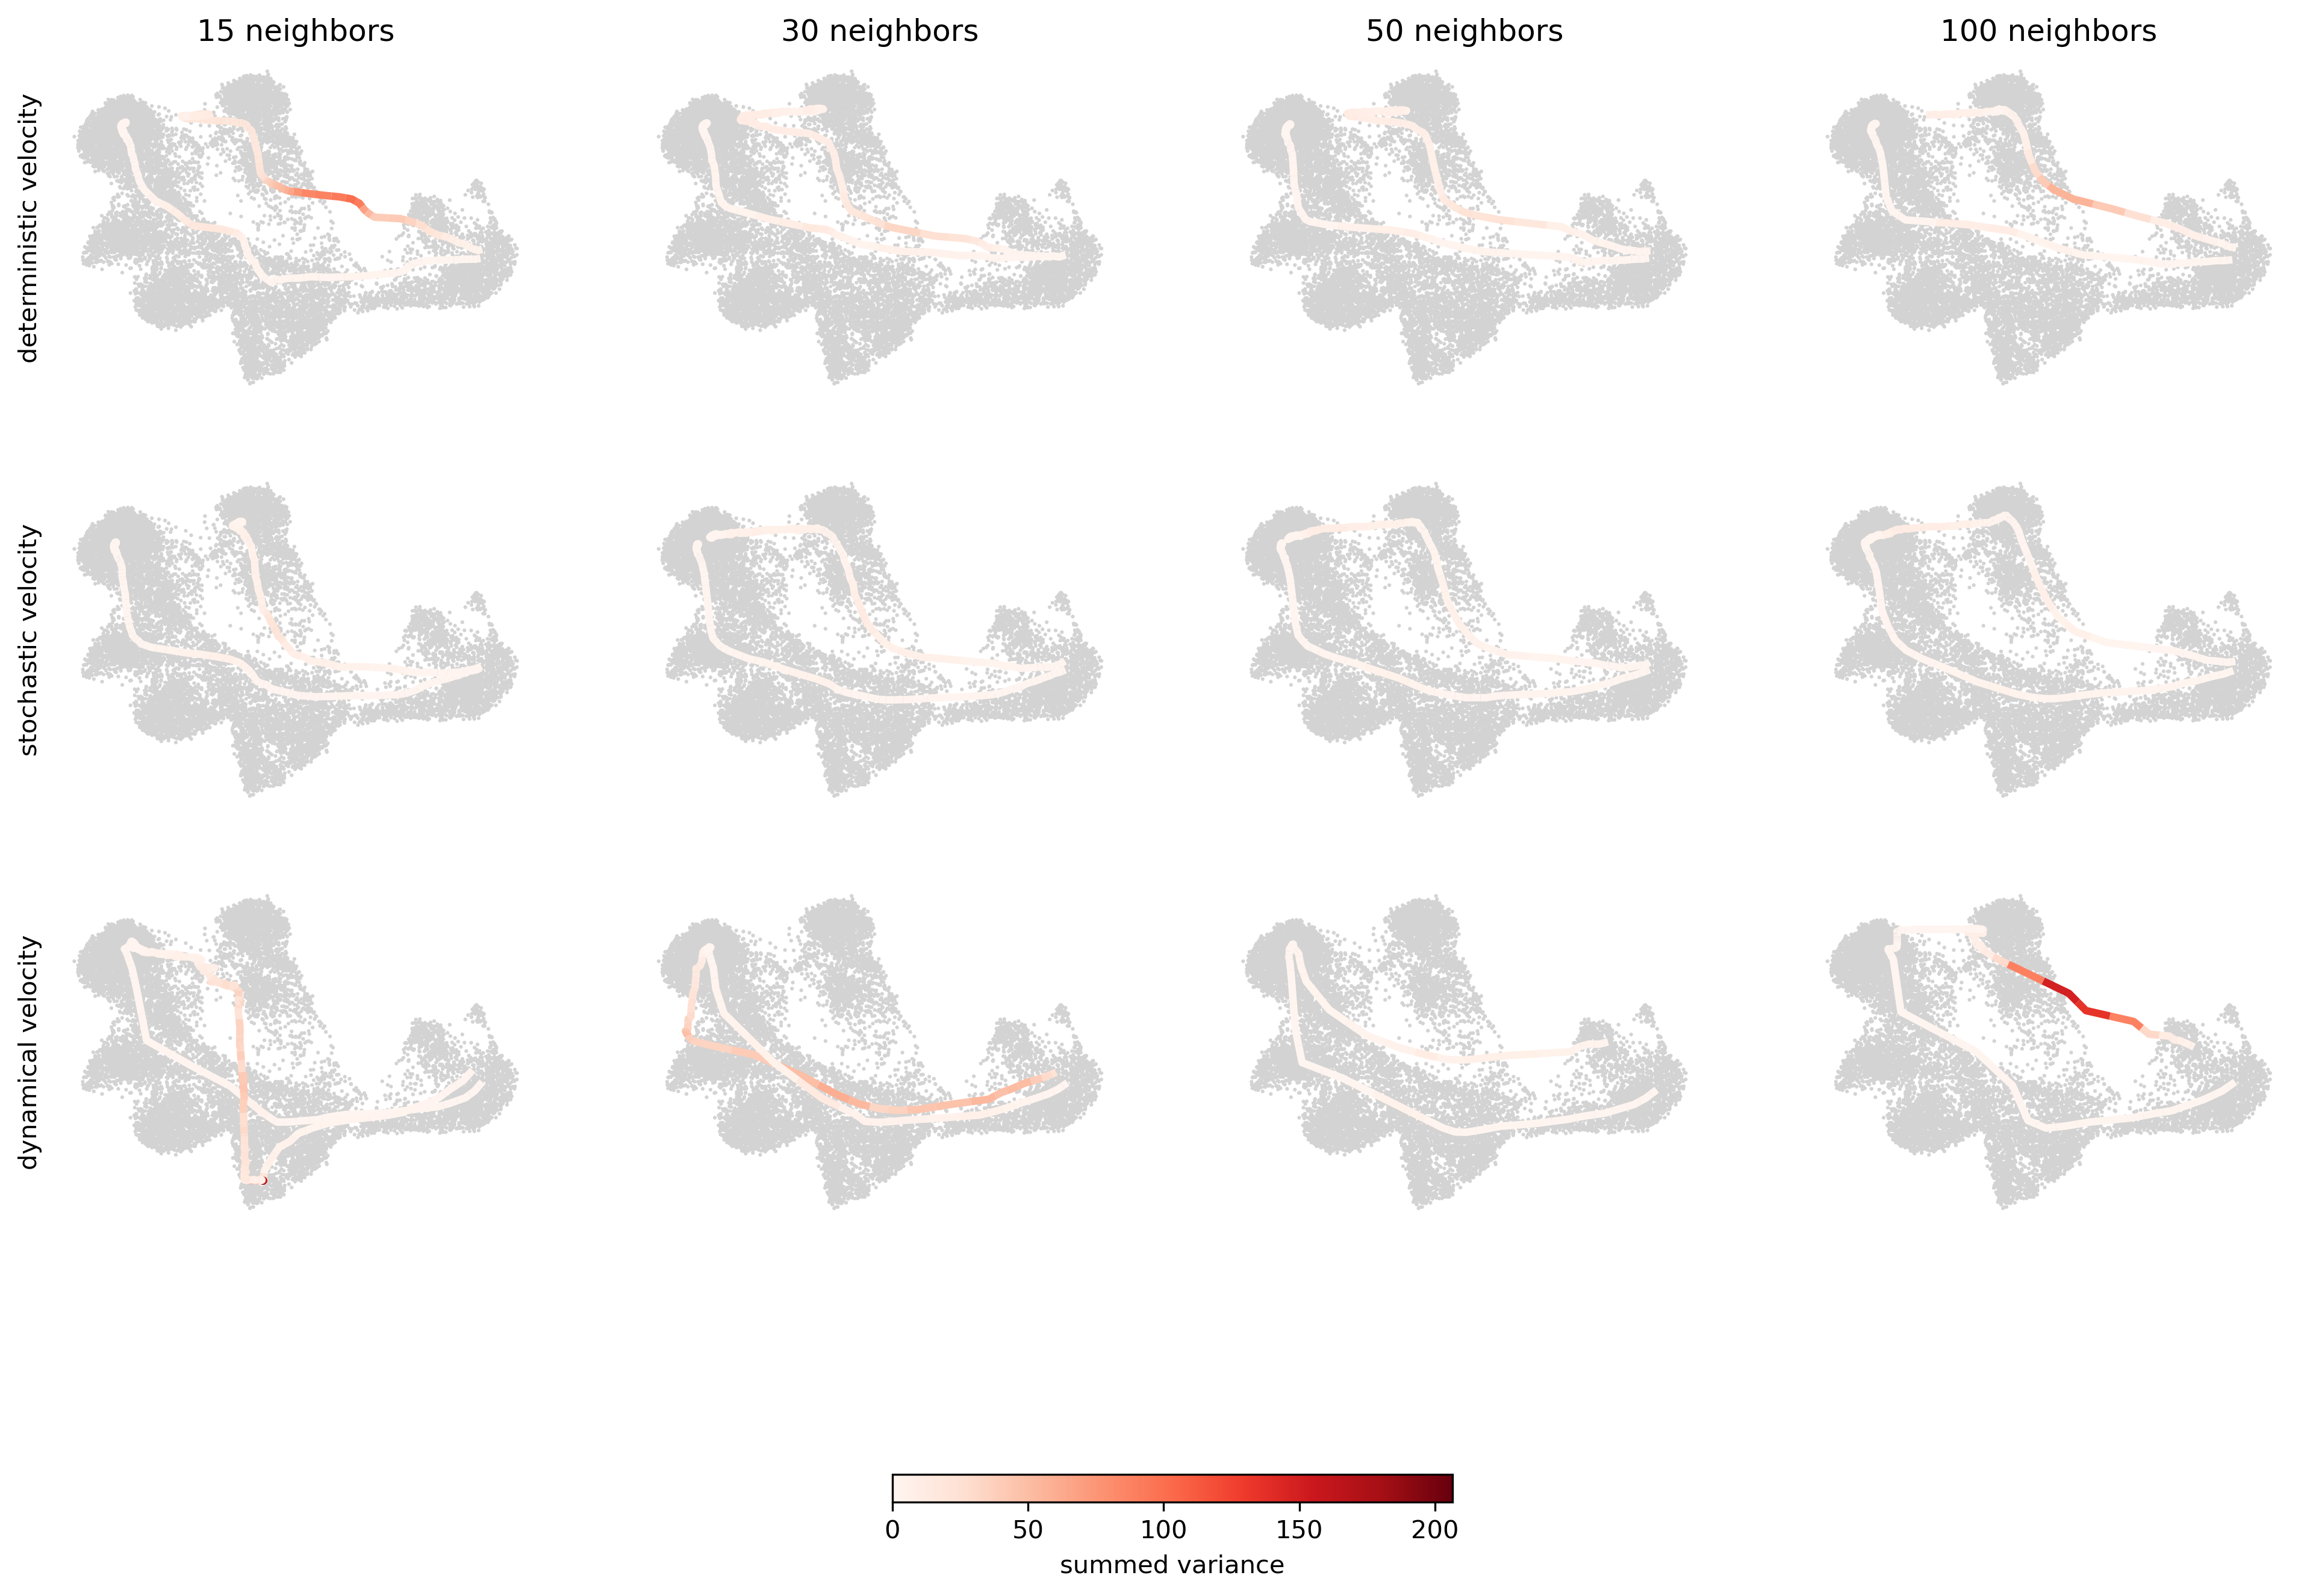

In [32]:
# Plot trajectories and their variance in PCA space
fig, axs = plt.subplots(3, 4, figsize=(16, 12))
for row_idx, velocity_mode in enumerate(velocity_modes):
    for col_idx, n_neighbors in enumerate(n_neighbors_list):
        ax = axs[row_idx, col_idx]
        sc.pl.umap(adata, ax=ax, show=False)
        for j, lineage in enumerate(lineage_coords_mean[n_neighbors, velocity_mode]):
            colored_line(
                lineage[:, 0],
                lineage[:, 1],
                lineage_coords_var_sum_pca[n_neighbors, velocity_mode][j],
                ax,
                lw=3,
                norm=norm_var,
                cmap=cmap,
            )
        if row_idx == 0:
            ax.set_title(f"{n_neighbors} neighbors")
        else:
            ax.set_title("")
        if col_idx == 0:
            ax.set_ylabel(f"{velocity_mode} velocity")
        else:
            ax.set_ylabel("")
        ax.set_xlabel("")
sns.despine(fig, bottom=True, left=True)
fig.colorbar(
    mpl.cm.ScalarMappable(cmap=cmap, norm=norm_var),
    ax=axs,
    orientation="horizontal",
    location="bottom",
    label="summed variance",
    shrink=0.25,
);